# Day12 2-full Quantum Feature Space Lab

Source: Google Drive Day12 `2-full.py`


Lab 1. Customer Dataset
   Age  Income  VIP
0   25      45    0
1   32      52    0
2   47      80    1
3   52      90    1


Lab 2. Feature
   Age  Income
0   25      45
1   32      52
2   47      80
3   52      90

Label
0    0
1    0
2    1
3    1
Name: VIP, dtype: int64


Lab 3. Classical Feature Space


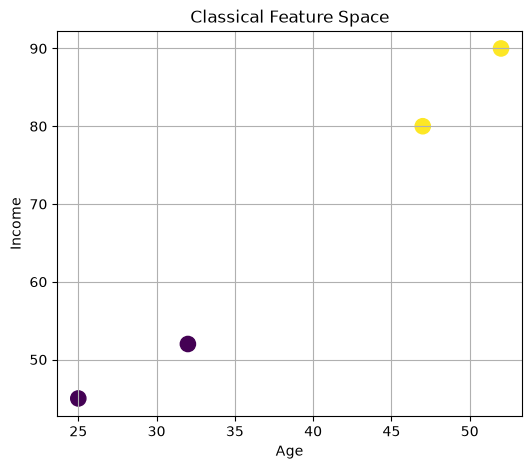



Lab 4. Quantum Circuit
     ┌───┐     
q_0: ┤ H ├──■──
     ├───┤┌─┴─┐
q_1: ┤ H ├┤ X ├
     └───┘└───┘


Lab 5. Feature Encoding
      ┌─────────┐  
q_0: ─┤ Ry(Age) ├──
     ┌┴─────────┴─┐
q_1: ┤ Ry(Income) ├
     └────────────┘


Lab 6. Quantum Feature Transformation
     ┌───┐ ┌─────────┐       
q_0: ┤ H ├─┤ Ry(Age) ├────■──
     ├───┤┌┴─────────┴─┐┌─┴─┐
q_1: ┤ H ├┤ Ry(Income) ├┤ X ├
     └───┘└────────────┘└───┘


Lab 7. Parameter Binding




Lab 8. ZZ Feature Map
   ┌───┐┌───────────┐                                          
0: ┤ H ├┤ P(2*x[0]) ├──■────────────────────────────────────■──
   ├───┤├───────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐
1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├
   └───┘└───────────┘└───┘└──────────────────────────────┘└───┘


Lab 9. Circuit Compare
===== My Circuit =====
     ┌───┐┌────────┐     
q_0: ┤ H ├┤ Ry(25) ├──■──
     ├───┤├────────┤┌─┴─┐
q_1: ┤ H ├┤ Ry(45) ├┤ X ├
     └───┘└────────┘└───┘

===== ZZ Feature Map =====
   ┌───┐┌───────────┐                                          
0: ┤ H ├┤ P(2*x[0]) ├──■────────────────────────────────────■──
   ├───┤├───────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐
1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├
   └───┘└───────────┘└───┘└──────────────────────────────┘└───┘


Lab 10. Quantum State
Statevector([-0.20544443+0.j, -0.6336271 +0.j, -0.72385666+0.j,
             -0.17983555+0.j],
           



Lab 13. Measurement


Lab 14. Aer Simulator
{'01': 407, '11': 34, '10': 540, '00': 43}


Lab 15. Histogram


Quantum Feature Space Lab Completed


In [1]:
############################################################
# Quantum Feature Space 실습
#
# 실습 목표
# 1. Classical Feature 확인
# 2. Quantum Circuit 생성
# 3. Feature Encoding
# 4. Quantum Feature Transformation
# 5. Quantum State 생성
# 6. Measurement 결과 확인
############################################################

import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector

from qiskit.circuit.library import zz_feature_map

from qiskit_aer import AerSimulator

from qiskit.visualization import (
    plot_histogram,
    plot_bloch_multivector,
    plot_state_qsphere
)

############################################################
# Lab 1
# 고객 데이터 생성
############################################################

print("=" * 70)
print("Lab 1. Customer Dataset")
print("=" * 70)

customer = pd.DataFrame({
    "Age": [25, 32, 47, 52],
    "Income": [45, 52, 80, 90],
    "VIP": [0, 0, 1, 1]
})

print(customer)

############################################################
# Lab 2
# Feature 확인
############################################################

print("\n")
print("=" * 70)
print("Lab 2. Feature")
print("=" * 70)

X = customer[["Age", "Income"]]
y = customer["VIP"]

print(X)

print("\nLabel")
print(y)

############################################################
# Lab 3
# Classical Feature Space
############################################################

print("\n")
print("=" * 70)
print("Lab 3. Classical Feature Space")
print("=" * 70)

plt.figure(figsize=(6,5))

plt.scatter(
    customer["Age"],
    customer["Income"],
    c=customer["VIP"],
    s=120
)

plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Classical Feature Space")

plt.grid(True)

plt.show()

############################################################
# Lab 4
# Quantum Circuit
############################################################

print("\n")
print("=" * 70)
print("Lab 4. Quantum Circuit")
print("=" * 70)

qc = QuantumCircuit(2)

qc.h(0)
qc.h(1)

qc.cx(0,1)

print(qc)

qc.draw("mpl")

plt.show()

############################################################
# Lab 5
# Feature Encoding
############################################################

print("\n")
print("=" * 70)
print("Lab 5. Feature Encoding")
print("=" * 70)

age = Parameter("Age")
income = Parameter("Income")

encoding = QuantumCircuit(2)

encoding.ry(age,0)
encoding.ry(income,1)

print(encoding)

encoding.draw("mpl")

plt.show()

############################################################
# Lab 6
# Quantum Feature Transformation
############################################################

print("\n")
print("=" * 70)
print("Lab 6. Quantum Feature Transformation")
print("=" * 70)

feature_circuit = QuantumCircuit(2)

feature_circuit.h(0)
feature_circuit.h(1)

feature_circuit.ry(age,0)
feature_circuit.ry(income,1)

feature_circuit.cx(0,1)

print(feature_circuit)

feature_circuit.draw("mpl")

plt.show()

############################################################
# Lab 7
# Parameter Binding
############################################################

print("\n")
print("=" * 70)
print("Lab 7. Parameter Binding")
print("=" * 70)

bound_qc = feature_circuit.assign_parameters({
    age:25,
    income:45
})

bound_qc.draw("mpl")

plt.show()

############################################################
# Lab 8
# ZZ Feature Map
############################################################

print("\n")
print("=" * 70)
print("Lab 8. ZZ Feature Map")
print("=" * 70)

feature_map = zz_feature_map(
    feature_dimension=2,
    reps=1
)

print(feature_map)

feature_map.draw("mpl")

plt.show()

############################################################
# Lab 9
# Circuit 비교
############################################################

print("\n")
print("=" * 70)
print("Lab 9. Circuit Compare")
print("=" * 70)

print("===== My Circuit =====")
print(bound_qc)

print()

print("===== ZZ Feature Map =====")
print(feature_map)

############################################################
# Lab 10
# Quantum State 생성
############################################################

print("\n")
print("=" * 70)
print("Lab 10. Quantum State")
print("=" * 70)

state = Statevector.from_instruction(bound_qc)

print(state)

############################################################
# Lab 11
# Bloch Sphere
############################################################

print("\n")
print("=" * 70)
print("Lab 11. Bloch Sphere")
print("=" * 70)

plot_bloch_multivector(state)

plt.show()

############################################################
# Lab 12
# QSphere
############################################################

print("\n")
print("=" * 70)
print("Lab 12. QSphere")
print("=" * 70)

plot_state_qsphere(state)

plt.show()

############################################################
# Lab 13
# Measurement
############################################################

print("\n")
print("=" * 70)
print("Lab 13. Measurement")
print("=" * 70)

measure_qc = bound_qc.copy()

measure_qc.measure_all()

measure_qc.draw("mpl")

plt.show()

############################################################
# Lab 14
# Aer Simulator
############################################################

print("\n")
print("=" * 70)
print("Lab 14. Aer Simulator")
print("=" * 70)

sim = AerSimulator()

job = sim.run(
    measure_qc,
    shots=1024
)

result = job.result()

counts = result.get_counts()

print(counts)

############################################################
# Lab 15
# Histogram
############################################################

print("\n")
print("=" * 70)
print("Lab 15. Histogram")
print("=" * 70)

plot_histogram(counts)

plt.show()

############################################################
# END
############################################################

print("\n")
print("=" * 70)
print("Quantum Feature Space Lab Completed")
print("=" * 70)
